<a href="https://colab.research.google.com/github/mc64532-alt/BCIS466-Semester-Project/blob/main/Bank_Marketing_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install ucimlrepo

In [10]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [11]:
import pandas as pd

# Concatenate independent features (X) and the target variable (y) into a single DataFrame
df = pd.concat([X, y], axis=1)

# Display the first 5 rows to inspect the data structure
display(df.head())

# Print a technical summary including row count, data types, and non-null values
df.info()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [12]:
# Statistical summary for numerical features
print("Numerical Features Summary:")
display(df.describe())

# Statistical summary for categorical features
print("\nCategorical Features Summary:")
display(df.describe(include=['object']))

# Check for missing values specifically
print("\nMissing Values Count:")
print(df.isnull().sum())

# Check the distribution of our target variable 'y'
print("\nTarget Variable Distribution:")
print(df['y'].value_counts(normalize=True))

Numerical Features Summary:


,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000



Categorical Features Summary:


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,44923,45211,43354,45211,45211,45211,32191,45211,8252,45211
unique,11,3,3,2,2,2,2,12,3,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,failure,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,4901,39922



Missing Values Count:
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64

Target Variable Distribution:
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


/tmp/ipykernel_8537/99564996.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='viridis')


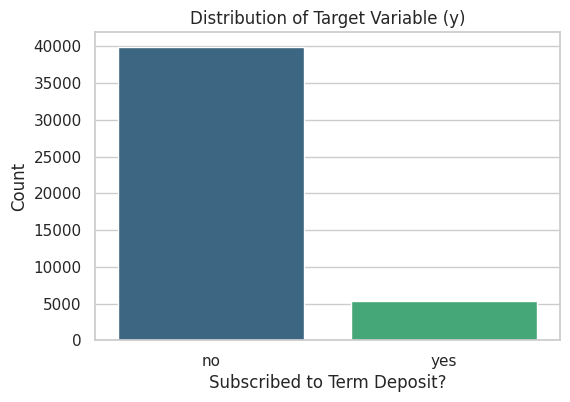

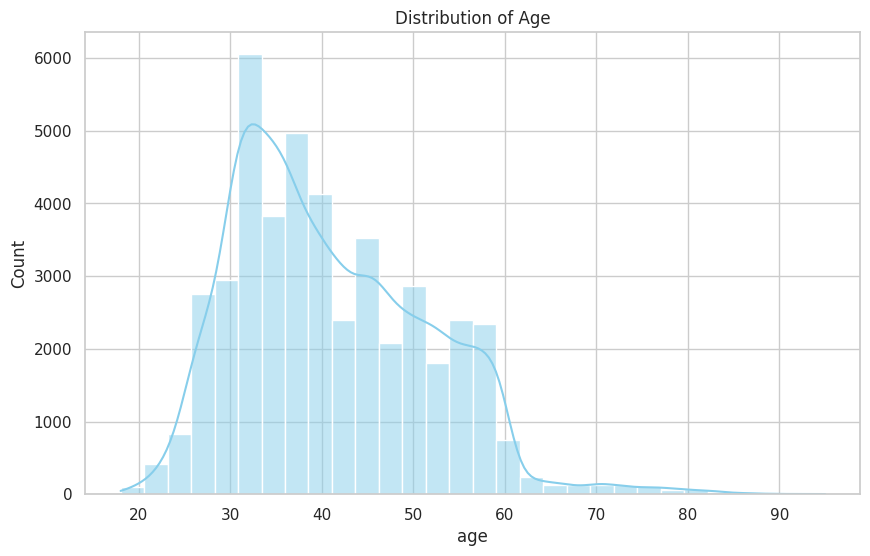

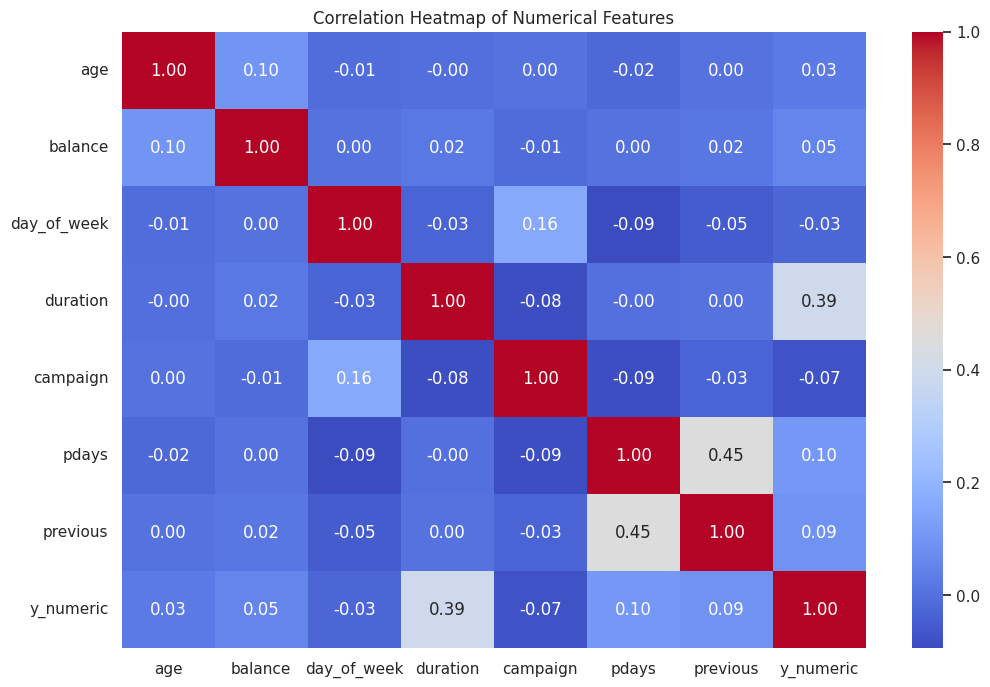

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Visualize the Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='viridis')
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Subscribed to Term Deposit?')
plt.ylabel('Count')
plt.show()

# Visualize Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.show()

# Correlation Heatmap (only for numerical features)
plt.figure(figsize=(12, 8))
# First, we need to convert target 'y' to numeric for the correlation matrix
df_corr = df.copy()
df_corr['y_numeric'] = df_corr['y'].map({'yes': 1, 'no': 0})
sns.heatmap(df_corr.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Handle Missing Values
# Given the high number of missing values in 'poutcome' and 'contact',
# we'll fill them with 'unknown' to keep the data points.
df_clean = df.copy()
df_clean['job'] = df_clean['job'].fillna('unknown')
df_clean['education'] = df_clean['education'].fillna('unknown')
df_clean['contact'] = df_clean['contact'].fillna('unknown')
df_clean['poutcome'] = df_clean['poutcome'].fillna('unknown')

# Binary Encoding for the Target variable 'y' (yes=1, no=0)
df_clean['y'] = df_clean['y'].map({'yes': 1, 'no': 0})

# One-Hot Encoding for categorical features
# This converts columns like 'marital' into multiple columns (marital_single, marital_married, etc.)
df_final = pd.get_dummies(df_clean, columns=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome'])

# Define Features (X) and Target (y)
X_final = df_final.drop('y', axis=1)
y_final = df_final['y']

# Split the data (80% Train, 20% Test)
# Using random_state ensures the results are reproducible
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.20, random_state=42)

print(f"Preprocessing complete. Training set size: {X_train.shape}, Test set size: {X_test.shape}")

Preprocessing complete. Training set size: (36168, 51), Test set size: (9043, 51)


Training models... please wait.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Model Performance Comparison ---
Logistic Regression: Accuracy = 0.8999, F1-Score = 0.4610
Random Forest: Accuracy = 0.9050, F1-Score = 0.5105


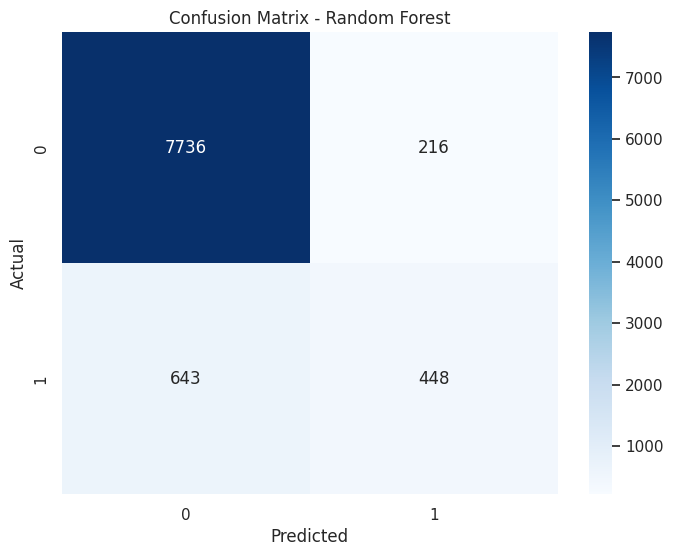

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the models
log_reg = LogisticRegression(max_iter=1000)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the models (The "Learning" phase)
print("Training models... please wait.")
log_reg.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

# Make predictions on the Test set (The "Exam" phase)
log_pred = log_reg.predict(X_test)
rf_pred = rf_clf.predict(X_test)

# Compare Results
models = ['Logistic Regression', 'Random Forest']
accuracies = [accuracy_score(y_test, log_pred), accuracy_score(y_test, rf_pred)]
f1_scores = [f1_score(y_test, log_pred), f1_score(y_test, rf_pred)]

print("\n--- Model Performance Comparison ---")
for i in range(len(models)):
    print(f"{models[i]}: Accuracy = {accuracies[i]:.4f}, F1-Score = {f1_scores[i]:.4f}")

# Visualizing the Confusion Matrix for the best model (usually Random Forest)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

/tmp/ipykernel_8537/134358326.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


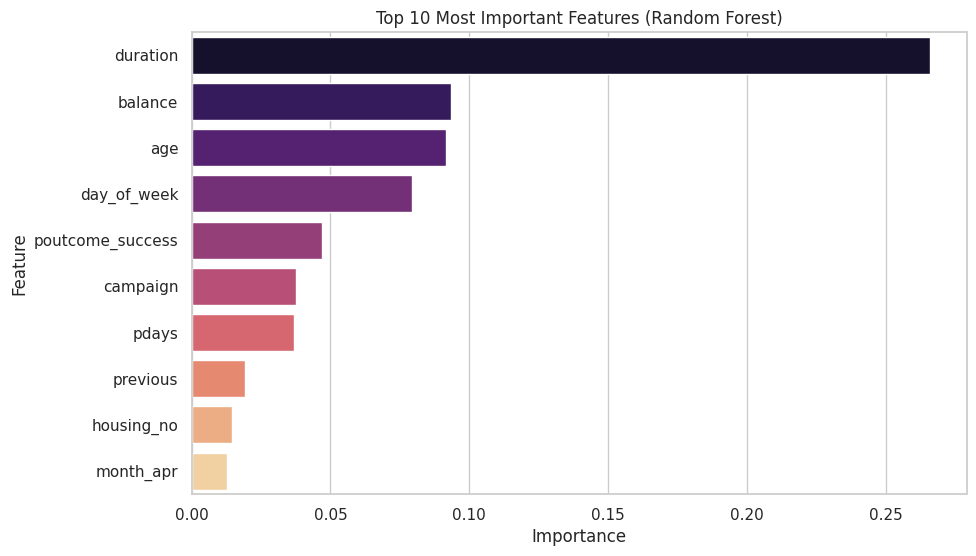

In [16]:
# Extract feature importance from the Random Forest model
importances = rf_clf.feature_importances_
feature_names = X_final.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.show()